In [2]:
!pip install opencv-python

In [3]:
# Librerias de vision, operaciones y visualizacion
import cv2
import numpy as np
import matplotlib.pyplot as plt

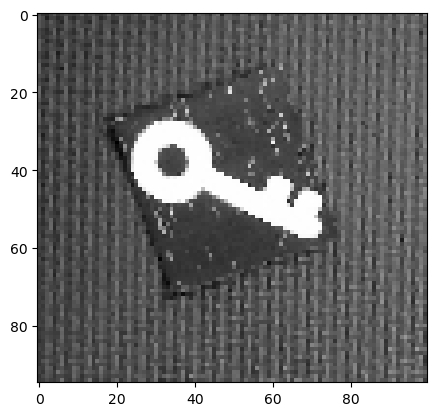

In [4]:
#lectura de la imagen
img = cv2.imread('/home/usr-lbr-maq20/Documentos/Diplomado-RNA/Modulo-3/Material/llave1.jpg')
escala = 1/8
img = cv2.resize(img, (round(escala*img.shape[1]), round(escala*img.shape[0]))) 
imgGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(imgGray, cmap='gray')
plt.show()


In [9]:
print("imagen 1 (Sin tratamiento)",img.shape)
print("imagen 2 (Con tratamiento)",imgGray.shape)

imagen 1 (Sin tratamiento) (95, 100, 3)
imagen 2 (Con tratamiento) (95, 100)


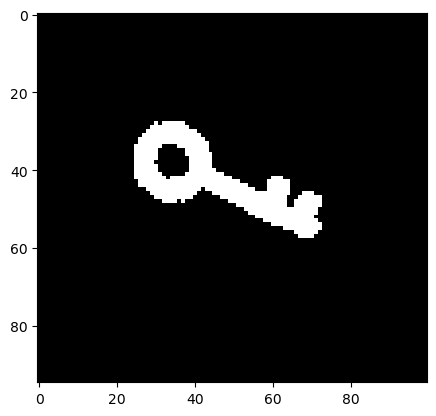

In [ ]:
#binarizado
t , imgBin = cv2.threshold(imgGray, 242, 1, cv2.THRESH_BINARY) #ponemos un umbral de 242, el valor maximo es 1, y el tipo de binarizacion es THRESH_BINARY
plt.imshow(imgBin, cmap='gray')
plt.show()

Gradiente de la imagen

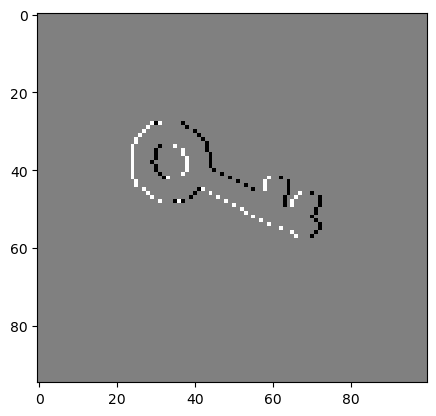

In [35]:
#Gradiente en x
kernel_x = [-1 , 1]
deri_x = np.zeros((imgBin.shape[0], imgBin.shape[1]))
for i in range(imgBin.shape[0]):
    for j in range(imgBin.shape[1]):
        conv = np.sum(kernel_x * imgBin[i, j:j+2])
        deri_x[i, j] = conv
plt.imshow(deri_x, cmap='gray')
plt.show()

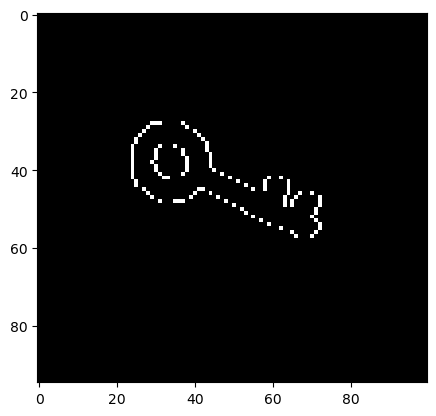

In [36]:
deri_x_abs = np.abs(deri_x)
plt.imshow(deri_x_abs, cmap='gray')
plt.show()

Gradiente en Y

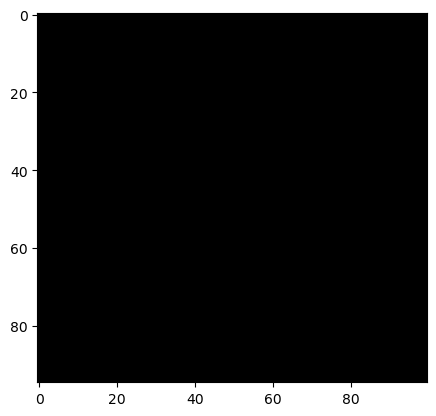

In [56]:
#Gradiente en y
kernel_y = [[-1], [1]]
deri_y = np.zeros((imgBin.shape[0], imgBin.shape[1]))
for i in range(imgBin.shape[0]):
    for j in range(imgBin.shape[1]):
        conv = np.sum(kernel_y * imgBin[i:i+2, j])
        deri_y[i, j] = conv
plt.imshow(deri_y, cmap='gray')
plt.show()

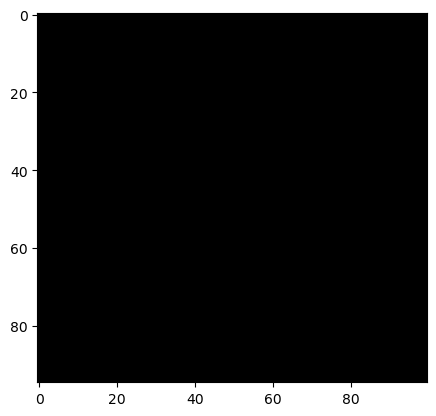

In [54]:
deri_y_abs = np.abs(deri_y)
plt.imshow(deri_y_abs, cmap='gray')
plt.show()

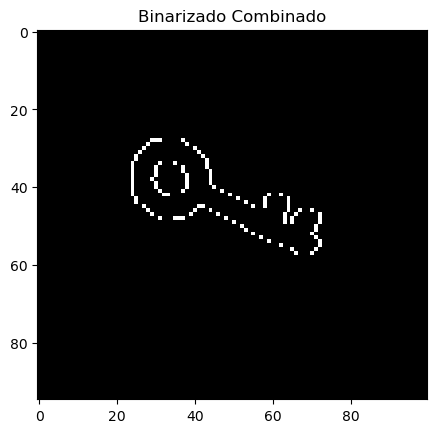

In [58]:
# Concatenamos las imágenes de la binarizada para obtener una imagen con los bordes detectados en ambas direcciones
binario_combined = cv2.bitwise_or(deri_x_abs.astype(np.uint8), deri_y_abs.astype(np.uint8))
plt.imshow(binario_combined, cmap='gray')
plt.title('Binarizado Combinado')
plt.show()

Con Algoritmo Sobel

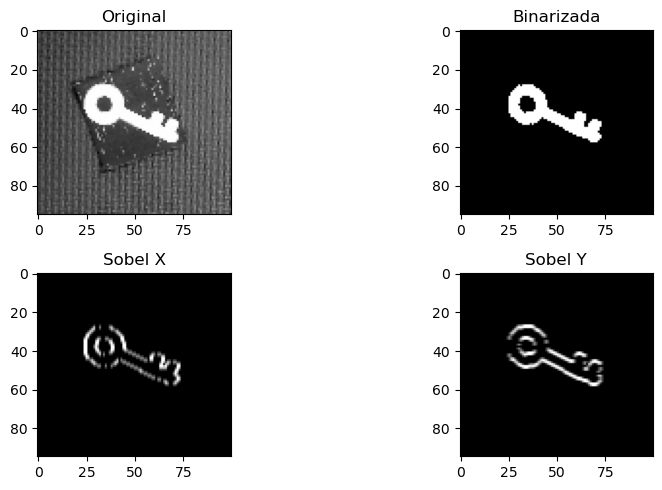

In [ ]:
sobelx = cv2.Sobel(imgBin, cv2.CV_64F, 1, 0, ksize=3)
sobel_x_abs = np.abs(sobelx)
sobely = cv2.Sobel(imgBin, cv2.CV_64F, 0, 1, ksize=3)
sobel_y_abs = np.abs(sobely)


plt.figure(figsize=(10, 5))
plt.subplot(2,2,1)
plt.imshow(imgGray, cmap='gray')
plt.title('Original')
plt.subplot(2,2,2)
plt.imshow(imgBin, cmap='gray')
plt.title('Binarizada')
plt.subplot(2,2,3)
plt.imshow(sobel_x_abs, cmap='gray')
plt.title('Sobel X')
plt.subplot(2,2,4)
plt.imshow(sobel_y_abs, cmap='gray')
plt.title('Sobel Y')
plt.tight_layout()
plt.show()


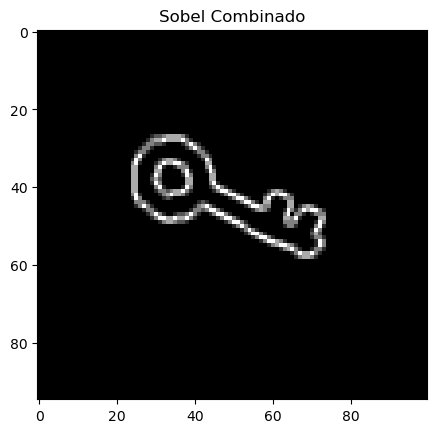

In [49]:
# Concatenamos las 2 imagenes de sobel para obtener una imagen con los bordes detectados en ambas direcciones
sobel_combined = cv2.bitwise_or(sobel_x_abs.astype(np.uint8), sobel_y_abs.astype(np.uint8))
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Combinado')
plt.show()


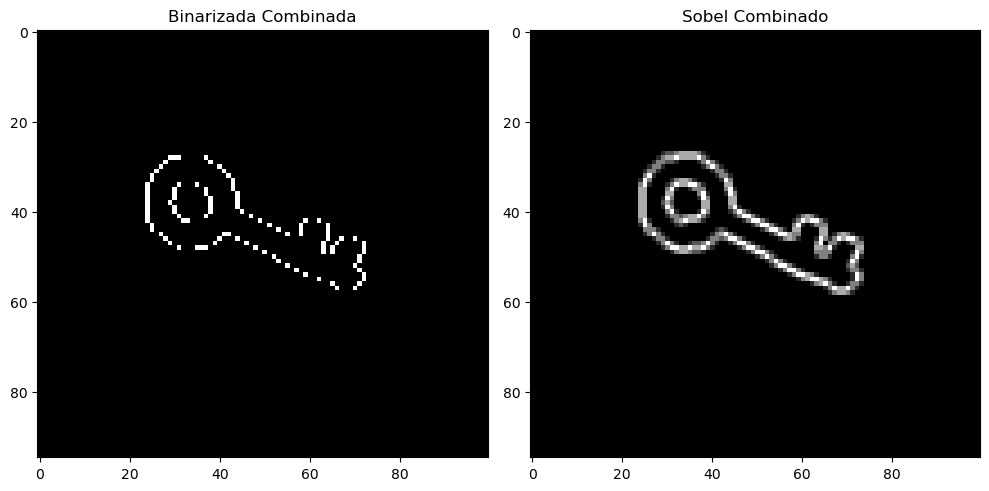

In [59]:
# Generamos una tabla para comparar los resultados la concatenacion de los diferentes metodos de deteccion de bordes entre binario y sobel combinado

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(binario_combined, cmap='gray')
plt.title('Binarizada Combinada')
plt.subplot(1,2,2)
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Combinado')
plt.tight_layout()
plt.show()
